In [20]:
# [ADDED] worked example – run this cell
# Environment check – run in each environment and include the output in your report
import sys, platform, importlib
print("Python version :", sys.version.split()[0])
print("Executable     :", sys.executable)
print("Operating sys. :", platform.system(), platform.release())
for pkg in ["numpy", "pandas", "matplotlib", "sklearn", "statsmodels", "ISLP"]:
    try:
        m = importlib.import_module(pkg)
        print(f"{pkg:<12} {getattr(m, '__version__', 'installed')}")
    except ImportError:
        print(f"{pkg:<12} NOT INSTALLED – run the Setup cell / pip install ISLP")

Python version : 3.14.7
Executable     : d:\DOWNLOADS\Statistical learning\IT171IU_Labs\.venv\Scripts\python.exe
Operating sys. : Windows 10
numpy        2.5.3
pandas       2.3.3
matplotlib   3.11.2
sklearn      1.9.1
statsmodels  0.15.0
ISLP         0.4.1


In [21]:
# ✍️ Task 0 – environment check in two environments – your code
# Write your code below (replace th e TODOs), then run the cell (Shift+Enter).
full_name = "Nguyen Anh Tú"     # <- replace with your full name
print(f"Hello, {full_name}! My statistical-learning environment works.")


Hello, Nguyen Anh Tú! My statistical-learning environment works.


In [ ]:
# [ADDED]
# 0. Setup – run this cell first (installs missing packages and fetches data files).
# On Google Colab the first run takes about 1 minute. If Colab asks you to
# "Restart session", accept, then run this cell once more.
import sys, os, subprocess, importlib.util, urllib.request

def ensure(module, pip_name=None):
    """pip-install a package only if it cannot be imported yet."""
    if importlib.util.find_spec(module) is None:
        print(f"Installing {pip_name or module} ...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pip_name or module], check=True)

ensure("ISLP", "ISLP")

# data files used by this lab (downloaded from the official ISLP_labs repository if missing)
BASE_URL = "https://raw.githubusercontent.com/intro-stat-learning/ISLP_labs/v2.2.3/"
for fname in ['Auto.csv', 'Auto.data']:
    if not os.path.exists(fname):
        os.makedirs(os.path.dirname(fname) or ".", exist_ok=True)
        #urllib.request.urlretrieve(BASE_URL + fname, fname)

print("Setup complete – Python", sys.version.split()[0])

Setup complete – Python 3.14.7


In [23]:
print('fit a model with', 11, 'variables')

fit a model with 11 variables


In [24]:
import numpy as np


<span style="color:red">Solve the exercises in the ✍️ cells of the notebook. For every exercise write **code + output + 1–3 sentences of interpretation**. Exercises 1–7 are compulsory; 8–9 are challenge (bonus) exercises.</span>

## <span style="color:red">Exercise 1 – NumPy warm-up</span>

- <span style="color:red">**(a)** Create the vector $v = (2, 4, 6, \dots, 40)$ with `np.arange()` and reshape it into a $4\times5$ matrix `M`.</span>
- <span style="color:red">**(b)** Print `M.shape`, `M.ndim`, `M.dtype` and the transpose `M.T`.</span>
- <span style="color:red">**(c)** Extract the second row, the last column and the sub-matrix of rows 2–3 and columns 1–3 (1-based counting) using slices.</span>
- <span style="color:red">**(d)** Compute row means and column standard deviations with the `axis` argument.</span>
- <span style="color:red">**(e)** Set `B = M[:2, :2]`, then `B[0, 0] = -1`. Did `M` change? Repeat with `B = M[:2, :2].copy()` and explain the difference.</span>

In [25]:
import numpy as np
# (a)
# TODO (a): Create the vector with np.arange() 
# Vector v = (2, 4, 6, ..., 40)
v = np.arange(2, 42, 2)

# TODO (a): reshape it into a 4x5 matrix M
M = v.reshape((4, 5))
print("Matrix M:\n", M)

Matrix M:
 [[ 2  4  6  8 10]
 [12 14 16 18 20]
 [22 24 26 28 30]
 [32 34 36 38 40]]


In [26]:
if M is not None:
    print(M.shape, M.ndim, M.dtype)   # (b)
    print(M.T)

(4, 5) 2 int64
[[ 2 12 22 32]
 [ 4 14 24 34]
 [ 6 16 26 36]
 [ 8 18 28 38]
 [10 20 30 40]]


In [27]:
# (c)
print("Second row:\n", M[1, :])
print("Last column:\n", M[:, -1])
print("Sub-matrix (rows 2-3, cols 1-3):\n", M[1:3, 0:3])

Second row:
 [12 14 16 18 20]
Last column:
 [10 20 30 40]
Sub-matrix (rows 2-3, cols 1-3):
 [[12 14 16]
 [22 24 26]]


In [28]:
# (d)
print("Row means:", M.mean(axis=1))
print("Column standard deviations:", M.std(axis=0))

Row means: [ 6. 16. 26. 36.]
Column standard deviations: [11.18033989 11.18033989 11.18033989 11.18033989 11.18033989]


In [29]:
# (e)
B = M[:2, :2]
B[0, 0] = -1
print("Modified B:\n", M[0, 0])

M[0, 0] = 2
B_copy = M[:2, :2].copy()
B_copy[0, 0] = -1
print("Copy of B (modified):\n", M[0, 0])


Modified B:
 -1
Copy of B (modified):
 2


## <span style="color:red">Exercise 2 – Random numbers, correlation and a saved figure</span>

- <span style="color:red">**(a)** Create `rng = np.random.default_rng(2026)` and simulate $n = 100$ values $x_i \sim N(0,1)$ and $\varepsilon_i \sim N(0, 0.5^2)$.</span>
- <span style="color:red">**(b)** Compute $y_i = 2 + 3x_i + \varepsilon_i$. What is the correlation between $x$ and $y$ (`np.corrcoef`)?</span>
- <span style="color:red">**(c)** Draw a scatter plot of $y$ against $x$ with axis labels and a title, add the true line $y = 2 + 3x$ in red, and save the figure as `ex2_scatter.png` (dpi = 150).</span>
- <span style="color:red">**(d)** Re-run the cell: are the numbers the same? What happens if you remove the seed?</span>

In [30]:
import numpy as np
from matplotlib.pyplot import subplots
# (a)
rng = np.random.default_rng(2026)
x = rng.standard_normal(100)
eps = 0.5   * rng.standard_normal(100) 



In [31]:
# (b)
y = 2 + 3 * x + eps
print("Correlation between x and y:", np.corrcoef(x, y)[0, 1])

Correlation between x and y: 0.9820330014880412


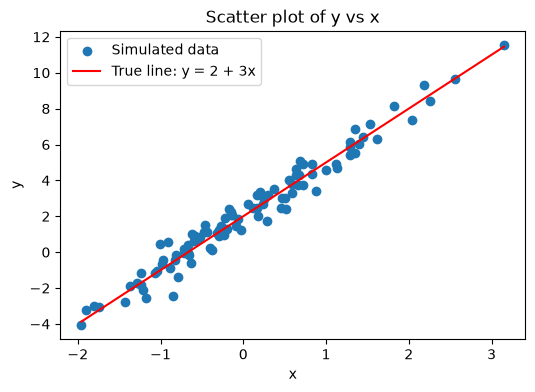

In [32]:
# (c)
from matplotlib.pyplot import subplots
fig, ax = subplots(figsize=(6, 4))
ax.scatter(x, y, marker='o', label='Simulated data')
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, 2 + 3 * x_line, color='red', label="True line: y = 2 + 3x")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
ax.set_title('Scatter plot of y vs x')

fig.savefig("ex2_scatter.png", dpi=150)


## <span style="color:red">Exercise 3 – Cleaning the `Auto` data</span>

- <span style="color:red">**(a)** Read `Auto.data` with `pd.read_csv(..., sep=r"\s+", na_values=["?"])`. How many rows contain at least one missing value? Remove them with `dropna()`.</span>
- <span style="color:red">**(b)** Which variables are **quantitative** and which are **qualitative**? Convert `origin` into a categorical variable with the labels *America* (1), *Europe* (2), *Japan* (3) – hint: `Auto["origin"].map({1: "America", 2: "Europe", 3: "Japan"})`.</span>
- <span style="color:red">**(c)** For every quantitative variable report its **range, mean and standard deviation** in one table (`describe()` or `agg(["min", "max", "mean", "std"])`).</span>

In [33]:
import pandas as pd
# (a)
Auto_raw = pd.read_csv("ISLP-datasets/Auto.csv", na_values=["?"])
total_rows = Auto_raw.shape[0]
print("Total rows in Auto_raw:", total_rows)
Auto_clean = Auto_raw.dropna()
print("Total rows after dropping missing values:", Auto_clean.shape[0])
n_missing = total_rows - Auto_clean.shape[0]
print("Number of missing values dropped:", n_missing)

Total rows in Auto_raw: 392
Total rows after dropping missing values: 392
Number of missing values dropped: 0


In [34]:
# (b)
print("Qualitative variables: origin, name")
print("Quantitative variables: mpg, cylinders, displacement, horsepower, weight, acceleration, year\n")

Auto_clean = Auto_clean.copy()
Auto_clean["origin"] = Auto_clean["origin"].map({1: "America", 2: "Europe", 3: "Japan"})

print(Auto_clean["origin"].head())

Qualitative variables: origin, name
Quantitative variables: mpg, cylinders, displacement, horsepower, weight, acceleration, year

0    America
1    America
2    America
3    America
4    America
Name: origin, dtype: object


In [35]:
# (c)
quantitative = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "year"]
stats_table = Auto_clean[quantitative].agg(["min", "max", "mean", "std"]).T
stats_table["range"] = stats_table["max"] - stats_table["min"]
stats_table = stats_table[["range", "mean", "std"]]
stats_table

,range,mean,std
mpg,37.6,23.445918,7.805007
cylinders,5.0,5.471939,1.705783
displacement,387.0,194.411990,104.644004
horsepower,184.0,104.469388,38.491160
weight,3527.0,2977.584184,849.402560
acceleration,16.8,15.541327,2.758864
year,12.0,75.979592,3.683737


## <span style="color:red">Exercise 4 – Subsetting rows with `iloc[]`</span>

<span style="color:red">Using the cleaned data from Exercise 3, remove the **10th through 85th observations** (1-based) and recompute the range, mean and standard deviation of each quantitative variable. Which statistics change the most? Why might that be?</span>

In [36]:
# ✍️ Exercise 4 – your code
# Write your code below (replace the TODOs), then run the cell (Shift+Enter).
keep = np.r_[0:9, 85:len(Auto_clean)]
Auto_sub = Auto_clean.iloc[keep]
summary_sub = Auto_sub[quant_cols].agg(["min", "max", "mean", "std"]).T
summary_sub["range"] = summary_sub["max"] - summary_sub["min"]
print("Remove the 10th through 85th observations:")
print(summary_sub[["range", "mean", "std"]])

NameError: name 'quant_cols' is not defined

## <span style="color:red">Exercise 5 – Graphical exploration</span>

- <span style="color:red">**(a)** Produce a scatter-plot matrix of `mpg`, `displacement`, `horsepower`, `weight` and `acceleration` (`pd.plotting.scatter_matrix`).</span>
- <span style="color:red">**(b)** Draw side-by-side box plots of `mpg` by `origin` and by `cylinders`.</span>
- <span style="color:red">**(c)** Write **three findings** in the work area. Which variables look useful for **predicting `mpg`**, and is the relationship linear?</span>

array([[<Axes: xlabel='mpg', ylabel='mpg'>,
        <Axes: xlabel='displacement', ylabel='mpg'>,
        <Axes: xlabel='horsepower', ylabel='mpg'>,
        <Axes: xlabel='weight', ylabel='mpg'>,
        <Axes: xlabel='acceleration', ylabel='mpg'>],
       [<Axes: xlabel='mpg', ylabel='displacement'>,
        <Axes: xlabel='displacement', ylabel='displacement'>,
        <Axes: xlabel='horsepower', ylabel='displacement'>,
        <Axes: xlabel='weight', ylabel='displacement'>,
        <Axes: xlabel='acceleration', ylabel='displacement'>],
       [<Axes: xlabel='mpg', ylabel='horsepower'>,
        <Axes: xlabel='displacement', ylabel='horsepower'>,
        <Axes: xlabel='horsepower', ylabel='horsepower'>,
        <Axes: xlabel='weight', ylabel='horsepower'>,
        <Axes: xlabel='acceleration', ylabel='horsepower'>],
       [<Axes: xlabel='mpg', ylabel='weight'>,
        <Axes: xlabel='displacement', ylabel='weight'>,
        <Axes: xlabel='horsepower', ylabel='weight'>,
        <Axes: x

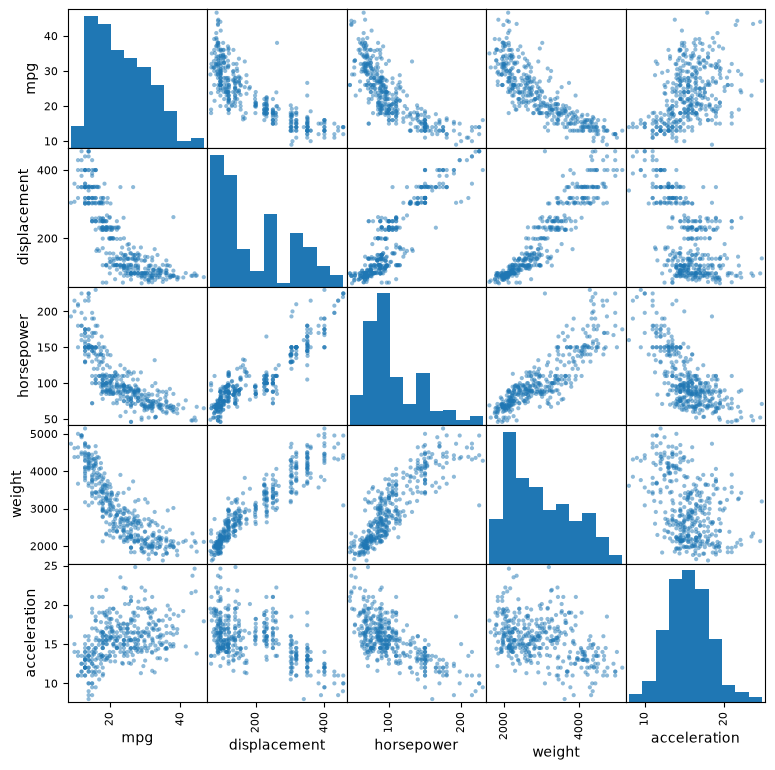

In [ ]:
#(a)
pd.plotting.scatter_matrix(
    Auto_clean[["mpg", "displacement", "horsepower", "weight", "acceleration"]],
    figsize=(9, 9)
)

Text(0.5, 0.98, '')

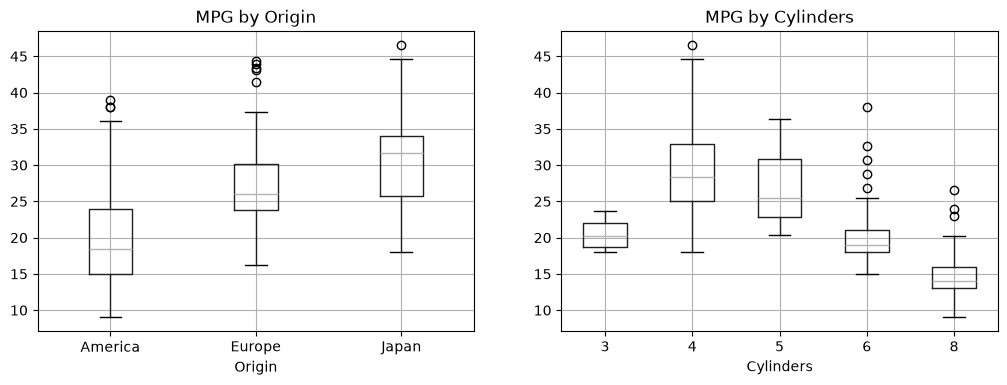

In [ ]:
# (b)
fig, axes = subplots(1, 2, figsize=(12, 4))

Auto_clean.boxplot("mpg", by="origin", ax=axes[0])
axes[0].set_title("MPG by Origin")
axes[0].set_xlabel("Origin")

Auto_clean.boxplot("mpg", by="cylinders", ax=axes[1])
axes[1].set_title("MPG by Cylinders")
axes[1].set_xlabel("Cylinders")

fig.suptitle("")

## <span style="color:red">Exercise 6 – The `College` data set</span>

<span style="color:red">The `College` data (777 US colleges) is available as `load_data("College")` from `ISLP`.</span>

- <span style="color:red">**(a)** Load it and print the first 5 rows and `College.describe()`.</span>
- <span style="color:red">**(b)** How many colleges are **private**?</span>
- <span style="color:red">**(c)** Create a new qualitative variable `Elite` that is `"Yes"` when more than 50% of new students come from the top 10% of their high-school class (`Top10perc > 50`). How many elite colleges are there?</span>
- <span style="color:red">**(d)** Draw box plots of `Outstate` (out-of-state tuition) versus `Private` and versus `Elite`.</span>
- <span style="color:red">**(e)** Make a $2 \times 2$ grid of histograms of four quantitative variables with different numbers of bins. Summarise what you see.</span>

In [ ]:
# (a)
from ISLP import load_data
College = load_data("College")
print("Dataset shape:", College.shape)
# (a) 
display(College.head())
display(College.describe())

Dataset shape: (777, 18)


,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


In [ ]:
# (b)
n_private = (College["Private"] == "Yes").sum()
print(f"Number of private colleges: {n_private}")

Number of private colleges: 565


In [ ]:
# (c)
College["Elite"] = "No"
College.loc[College["Top10perc"] > 50, "Elite"] = "Yes"
n_elite = (College["Elite"] == "Yes").sum()
print(f"The number of Elite colleges is: {n_elite}")

The number of Elite colleges is: 78


Text(0.5, 0.98, '')

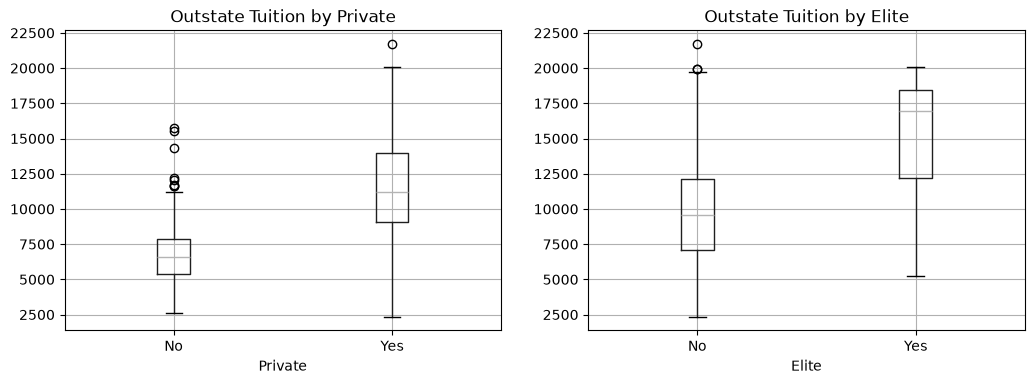

In [ ]:
# (d)
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
fig, axes = subplots(1, 2, figsize=(12, 4))

College.boxplot("Outstate", by="Private", ax=axes[0])
axes[0].set_title("Outstate Tuition by Private")
axes[0].set_xlabel("Private")

College.boxplot("Outstate", by="Elite", ax=axes[1])
axes[1].set_title("Outstate Tuition by Elite")
axes[1].set_xlabel("Elite")

fig.suptitle("")

Text(0.5, 1.0, 'Graduation Rate (bins=30)')

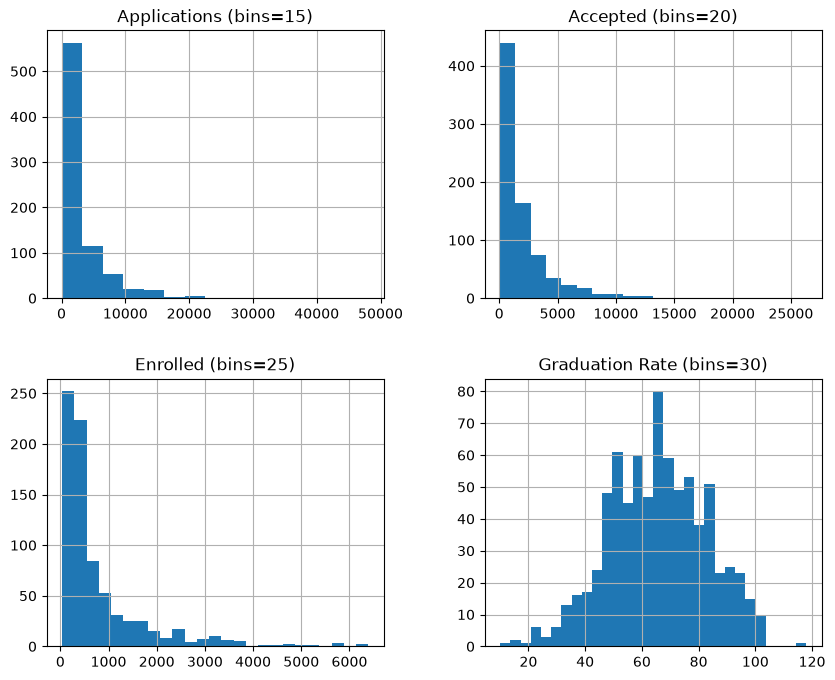

In [ ]:
# (e)
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
fig, axes = subplots(2, 2, figsize=(10, 8))
# four quantitative variables with different numbes of bins
College.hist("Apps", bins=15, ax=axes[0, 0])
axes[0, 0].set_title("Applications (bins=15)")

College.hist("Accept", bins=20, ax=axes[0, 1])
axes[0, 1].set_title("Accepted (bins=20)")

College.hist("Enroll", bins=25, ax=axes[1, 0])
axes[1, 0].set_title("Enrolled (bins=25)")

College.hist("Grad.Rate", bins=30, ax=axes[1, 1])
axes[1, 1].set_title("Graduation Rate (bins=30)")

## <span style="color:red">Exercise 7 – Loops and string formatting</span>

<span style="color:red">Write a `for` loop over the quantitative columns of `Auto_clean` that prints one formatted line per variable, for example</span>

<span style="color:red">*(added)*</span>
```text
horsepower   mean = 104.47  sd =  38.49  above-mean share = 37.0%
```

<span style="color:red">Use an f-string with field widths (`{name:<12}`), two decimals (`{value:.2f}`) and a percentage (`{share:.1%}`).</span>

In [ ]:
quantitative = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration"]

for col in quantitative:
    col_mean = Auto_clean[col].mean()
    col_sd = Auto_clean[col].std()
    above_mean_share = (Auto_clean[col] > col_mean).mean()
print(f"{col:<12} mean = {col_mean:.2f}  sd = {col_sd:.2f}  above-mean share = {above_mean_share:.1%}")

acceleration mean = 15.54  sd = 2.76  above-mean share = 45.7%


## <span style="color:red">Challenge exercises (optional, bonus)</span>

### <span style="color:red">Exercise 8 – Estimating bias and variance by simulation</span>

<span style="color:red">Use the set-up of Worked Example 1. Fix the test point $x_0 = 1$. For each degree $d \in \{1, 3, 5, 10, 15\}$ repeat 200 times: draw a new training set of size 60, fit the polynomial and store $\hat f(x_0)$. Estimate $\mathrm{Bias}^2 = (\overline{\hat f(x_0)} - f(x_0))^2$ and $\mathrm{Var}(\hat f(x_0))$ and plot both against $d$. Do the curves agree with the theory?</span>

Degree  1: Bias^2 = 1.1646, Variance = 0.0129
Degree  3: Bias^2 = 0.4440, Variance = 0.0258
Degree  5: Bias^2 = 0.0071, Variance = 0.0145
Degree 10: Bias^2 = 0.0000, Variance = 0.0237
Degree 15: Bias^2 = 0.0002, Variance = 0.0331


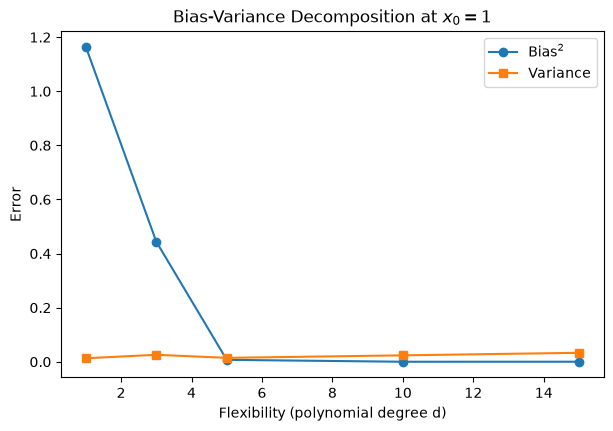

In [44]:
# ✍ Exercise 8 – your code
import numpy as np
from matplotlib.pyplot import subplots

rng = np.random.default_rng(171)
f = lambda x: np.sin(2 * x) + 0.5 * x
n_train, sigma = 60, 0.4

x0, n_rep = 1.0, 200
results = {}
bias2_list = []
var_list = []
degrees = [1, 3, 5, 10, 15]

for d in degrees:
    preds = []
    for r in range(n_rep):
        # TODO: simulate a training set, fit np.polyfit(..., deg=d), append
        x_tr = rng.uniform(-3, 3, n_train)
        y_tr = f(x_tr) + rng.normal(0, sigma, n_train)
        coef = np.polyfit(x_tr, y_tr, deg=d)
        preds.append(np.polyval(coef, x0))
        
    # TODO: results[d] = (bias2, variance)
    preds = np.array(preds)
    bias2 = (preds.mean() - f(x0))**2
    variance = preds.var()
    results[d] = (bias2, variance)
    
    bias2_list.append(bias2)
    var_list.append(variance)

for d in degrees:
    print(f"Degree {d:2d}: Bias^2 = {results[d][0]:.4f}, Variance = {results[d][1]:.4f}")

fig, ax = subplots(figsize=(7, 4.5))
ax.plot(degrees, bias2_list, 'o-', label=r'Bias$^2$')
ax.plot(degrees, var_list, 's-', label='Variance')
ax.set_xlabel('Flexibility (polynomial degree d)')
ax.set_ylabel('Error')
ax.set_title(r'Bias-Variance Decomposition at $x_0 = 1$')
ax.legend()


### <span style="color:red">Exercise 9 – Choosing $K$ for KNN</span>

<span style="color:red">Extend Worked Example 2: compute the **training** and **test** error rates for $K = 1, 2, \dots, 100$ and plot both against $1/K$ (log scale on the x-axis). Which $K$ minimises the test error? Relate the plot to Figure 2.17 of the textbook.</span>

In [46]:
# [ADDED] worked example – run this cell
rng = np.random.default_rng(2)
n = 200
X_tr = np.vstack([rng.normal([0, 0], 1, (n, 2)), rng.normal([1.5, 1.5], 1, (n, 2))])
y_tr = np.repeat([0, 1], n)
X_te = np.vstack([rng.normal([0, 0], 1, (500, 2)), rng.normal([1.5, 1.5], 1, (500, 2))])
y_te = np.repeat([0, 1], 500)

def knn_predict(X_train, y_train, X_new, K):
    # squared Euclidean distances between every new point and every training point
    d2 = ((X_new[:, None, :] - X_train[None, :, :])**2).sum(axis=2)
    nearest = np.argsort(d2, axis=1)[:, :K]          # indices of the K closest points
    return (y_train[nearest].mean(axis=1) > 0.5).astype(int)   # majority vote

for K in [1, 5, 15, 51, 151, 301]:
    err = np.mean(knn_predict(X_tr, y_tr, X_te, K) != y_te)
    print(f"K = {K:>3d}:  test error rate = {err:.3f}")

K =   1:  test error rate = 0.207
K =   5:  test error rate = 0.147
K =  15:  test error rate = 0.144
K =  51:  test error rate = 0.140
K = 151:  test error rate = 0.132
K = 301:  test error rate = 0.132


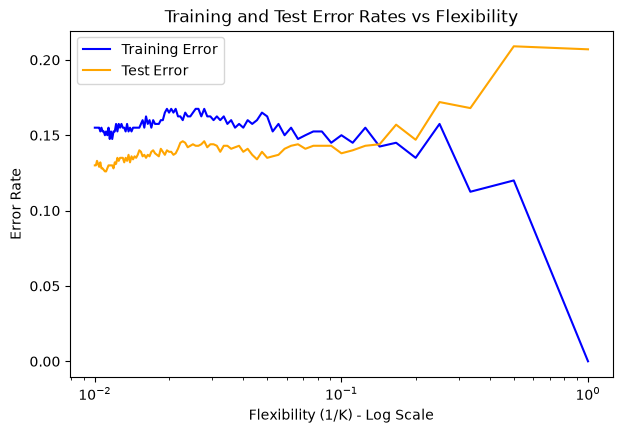

In [47]:
# ✍ Exercise 9 – your code
import numpy as np
from matplotlib.pyplot import subplots

Ks = list(range(1, 101))
train_err, test_err = [], []

# TODO: loop over Ks, call knn_predict(...) for the training and the test set, appe
for K in Ks:
    # Lưu ý: Hàm knn_predict, X_tr, y_tr, X_te, y_te đã được thầy nạp vào bộ nhớ ở Worked Example 2
    err_tr = np.mean(knn_predict(X_tr, y_tr, X_tr, K) != y_tr)
    train_err.append(err_tr)
    
    err_te = np.mean(knn_predict(X_tr, y_tr, X_te, K) != y_te)
    test_err.append(err_te)

best_K = Ks[int(np.argmin(test_err))]

fig, ax = subplots(figsize=(7, 4.5))
inv_K = [1 / k for k in Ks]

ax.plot(inv_K, train_err, label='Training Error', color='blue')
ax.plot(inv_K, test_err, label='Test Error', color='orange')
ax.set_xscale('log')
ax.set_xlabel('Flexibility (1/K) - Log Scale')
ax.set_ylabel('Error Rate')
ax.set_title('Training and Test Error Rates vs Flexibility')
ax.legend()